# Retail Sales & Inventory Optimization

## Project Overview
This project analyzes retail sales and inventory data to understand demand patterns, stock levels, and opportunities for inventory optimization.

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [2]:
# Loading raw retail inventory dataset

df = pd.read_csv("../data/raw/retail_inventory.csv")

# Preview data
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday,Competitor Pricing,Seasonality
0,01-01-2022,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,01-01-2022,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,01-01-2022,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,01-01-2022,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,01-01-2022,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


# Basic Dataset Inspection

In [3]:
# Shape of dataset
print("Dataset shape:", df.shape)

# Column names
df.columns

Dataset shape: (73100, 15)


Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', '         Holiday',
       'Competitor Pricing', 'Seasonality'],
      dtype='str')

In [4]:
# Data types and null check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12           Holiday    73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 8.4 MB


In [5]:
# Missing values count
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
         Holiday      0
Competitor Pricing    0
Seasonality           0
dtype: int64

# Summary Statistics

In [6]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


## Data Cleaning & Feature Engineering

In this step, we clean the raw retail inventory dataset and create new features required for sales and inventory analysis.

In [7]:
# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

# this avoids errors in SQL & Power BI later.

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'demand_forecast',
       'price', 'discount', 'weather_condition', 'holiday',
       'competitor_pricing', 'seasonality'],
      dtype='str')

In [8]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Check conversion
df['date'].head()

0   2022-01-01
1   2022-01-01
2   2022-01-01
3   2022-01-01
4   2022-01-01
Name: date, dtype: datetime64[us]

In [9]:
# Removing duplicate rows
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]

print(f"Removed {before - after} duplicate rows")

Removed 0 duplicate rows


# Feature Engineering (Time-Based)

In [10]:
# Extracting time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['years_month'] = df['date'].dt.to_period('M').astype(str)

df[['date', 'year', 'month', 'years_month']].head()

,date,year,month,years_month
0,2022-01-01,2022.0,1.0,2022-01
1,2022-01-01,2022.0,1.0,2022-01
2,2022-01-01,2022.0,1.0,2022-01
3,2022-01-01,2022.0,1.0,2022-01
4,2022-01-01,2022.0,1.0,2022-01


# Inventory Status Classification 

In [11]:
# Reorder point = forecast + safeety stock (20%)
df['reorder_point'] = df['demand_forecast'] * 1.2

In [12]:
def inventory_status(row):
    if row['inventory_level'] < row['reorder_point']:
        return 'Understock'
    elif row['inventory_level'] > row['reorder_point'] * 1.5:
        return 'Overstock'
    else:
        return 'Optimal'

df['inventory_status'] = df.apply(inventory_status, axis=1)

df['inventory_status'].value_counts()

inventory_status
Overstock     39070
Optimal       19969
Understock    14061
Name: count, dtype: int64

# Final Dataset Check

In [13]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                28900 non-null  datetime64[us]
 1   store_id            73100 non-null  str           
 2   product_id          73100 non-null  str           
 3   category            73100 non-null  str           
 4   region              73100 non-null  str           
 5   inventory_level     73100 non-null  int64         
 6   units_sold          73100 non-null  int64         
 7   units_ordered       73100 non-null  int64         
 8   demand_forecast     73100 non-null  float64       
 9   price               73100 non-null  float64       
 10  discount            73100 non-null  int64         
 11  weather_condition   73100 non-null  str           
 12  holiday             73100 non-null  int64         
 13  competitor_pricing  73100 non-null  float64       
 14  s

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,demand_forecast,price,discount,weather_condition,holiday,competitor_pricing,seasonality,year,month,years_month,reorder_point,inventory_status
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,2022.0,1.0,2022-01,162.564,Optimal
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,2022.0,1.0,2022-01,172.848,Optimal
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,2022.0,1.0,2022-01,88.824,Optimal
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,2022.0,1.0,2022-01,74.616,Overstock
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,2022.0,1.0,2022-01,11.112,Overstock


## Exploratory Data Analysis (EDA)

This section explores sales performance, revenue trends, product demand, and inventory health using visual analysis.

# Retail KPI Analysis

In [14]:
df['revenue'] = df['price'] * df['units_sold']

In [15]:
total_revenue = df['revenue'].sum()
total_units_sold = df['units_sold'].sum()
avg_inventory = df['inventory_level'].mean()

print("Total Revenue:", round(total_revenue, 2))
print("Total Units Sold:", total_units_sold)
print("Average Inventory Level:", round(avg_inventory, 2))

Total Revenue: 550228884.91
Total Units Sold: 9975582
Average Inventory Level: 274.47


In [16]:
# Stock-out Risk (Low Inventory Alert)

low_stock_threshold = df['inventory_level'].quantile(0.1)

stockout_risk = df[df['inventory_level'] <= low_stock_threshold]
print("Stock-out risk items:", stockout_risk.shape[0])

Stock-out risk items: 7387


In [17]:
# Overstock Analysis
high_stock_threshold = df['inventory_level'].quantile(0.9)

overstock_items = df[df['inventory_level'] >= high_stock_threshold]
print("Overstocked items:", overstock_items.shape[0])

Overstocked items: 7325


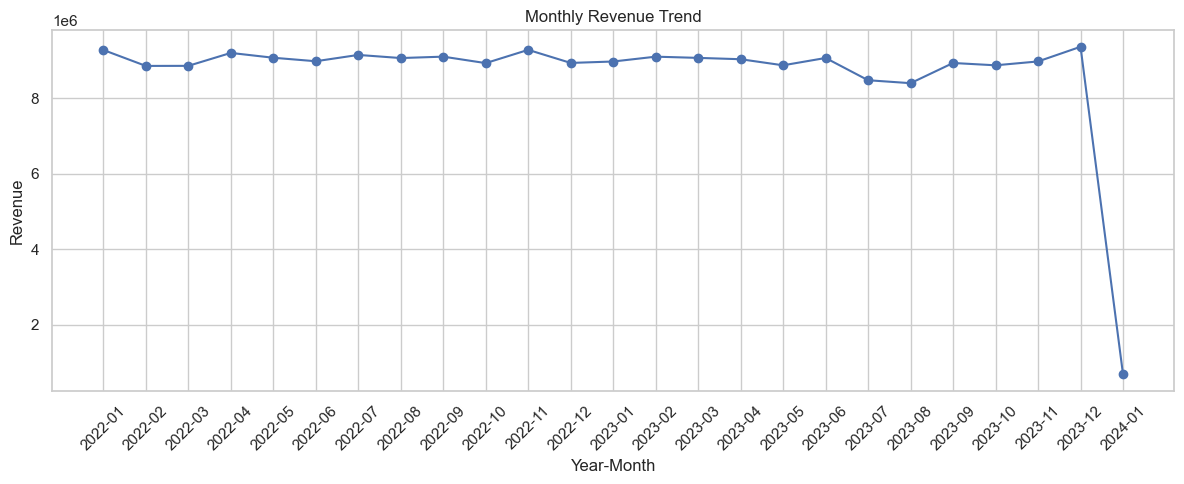

In [18]:
# Monthly Sales Trend 

monthly_sales = df.groupby('years_month')['revenue'].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales['years_month'], monthly_sales['revenue'], marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Category-wise Revenue Analysis

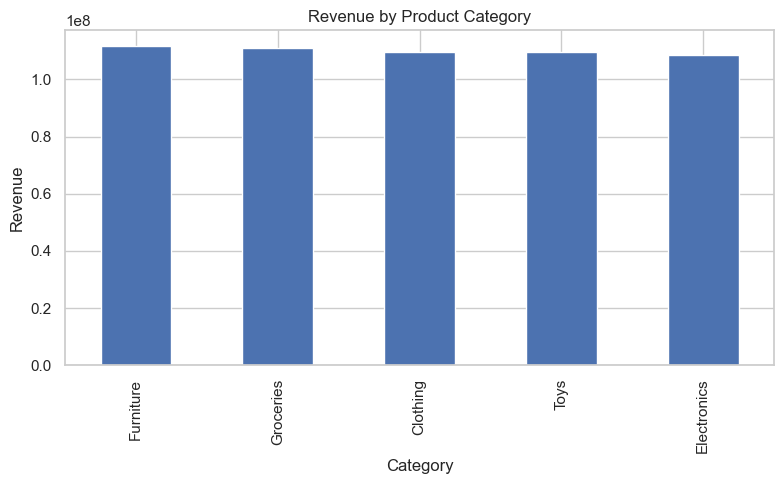

In [19]:
category_revenue = (
    df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Top 10 Products by Revenue

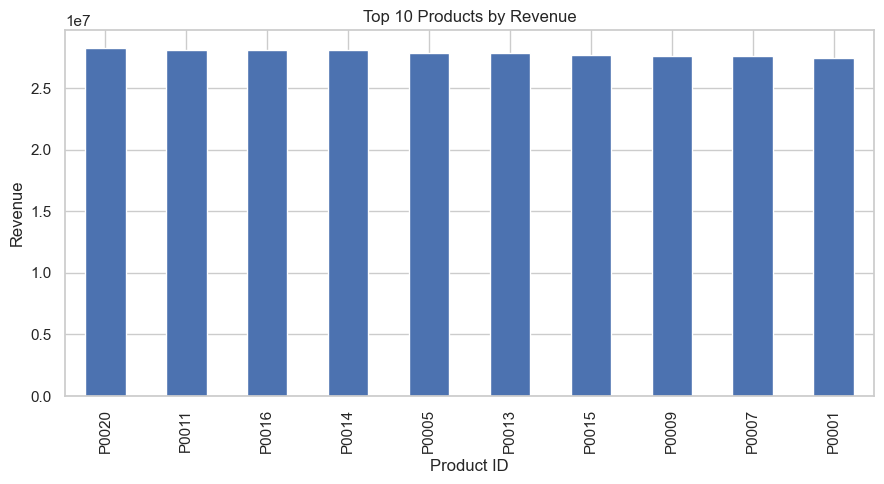

In [20]:
top_products = (
    df.groupby('product_id')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9,5))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product ID")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Inventory Status Distribution

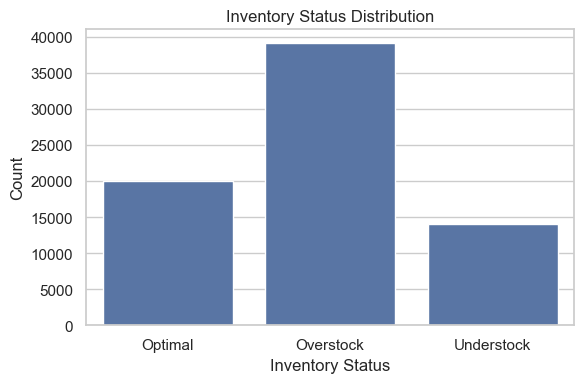

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='inventory_status', data=df)
plt.title("Inventory Status Distribution")
plt.xlabel("Inventory Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Units Sold VS Inventory Level

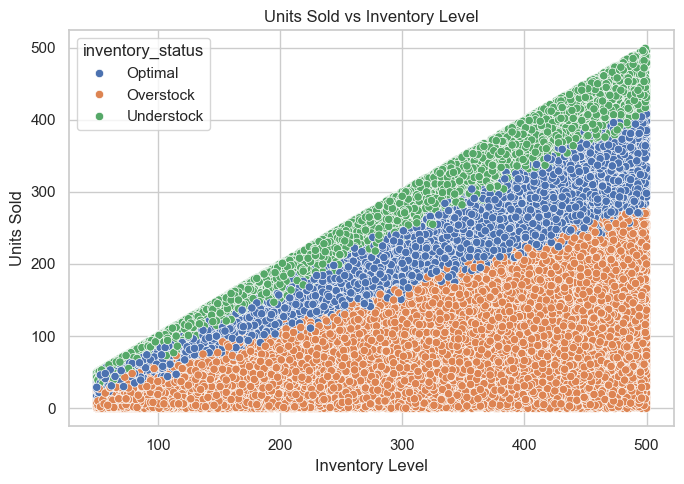

In [22]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='inventory_level',
    y='units_sold',
    hue='inventory_status',
    data=df
)
plt.title("Units Sold vs Inventory Level")
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

# Revenue Distribution

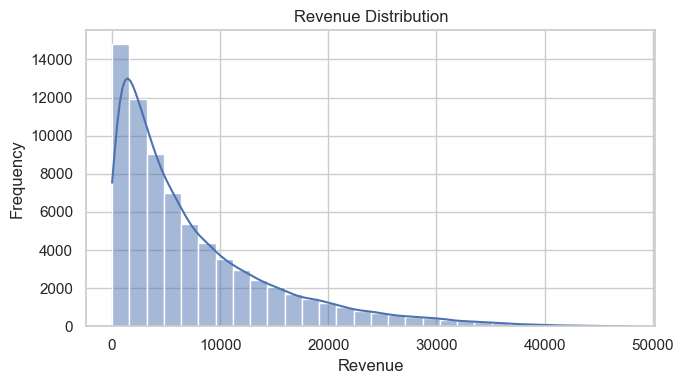

In [23]:
plt.figure(figsize=(7,4))
sns.histplot(df['revenue'], bins=30, kde=True)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Key EDA Observations

- Sales show clear monthly fluctuations, indicating seasonal demand patterns.
- A small number of products contribute a large portion of total revenue.
- Certain categories consistently outperform others in terms of revenue.
- A noticeable number of products fall under understock and overstock categories.
- Inventory levels are not always aligned with actual demand, indicating optimization opportunities.

# Saving Cleaned Dataset for MySQL & Power BI .

In [24]:
# Save cleaned dataset
df.to_csv("../data/cleaned_retail_inventory.csv", index=False)

In [25]:
df = pd.read_csv("../data/cleaned_retail_inventory.csv")

In [26]:
df['date'] = pd.to_datetime(
    df['date'],
    dayfirst=True,
    errors='coerce'
)

In [27]:
df[df['date'].isna()]

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,demand_forecast,price,discount,weather_condition,holiday,competitor_pricing,seasonality,year,month,years_month,reorder_point,inventory_status,revenue
1200,NaT,S001,P0001,Furniture,East,110,80,190,78.64,17.27,15,Snowy,1,21.79,Spring,NaN,NaN,NaN,94.368,Optimal,1381.60
1201,NaT,S001,P0002,Groceries,West,465,310,157,308.77,82.04,10,Rainy,0,83.15,Winter,NaN,NaN,NaN,370.524,Optimal,25432.40
1202,NaT,S001,P0003,Groceries,East,50,1,101,10.70,69.18,10,Rainy,1,66.84,Summer,NaN,NaN,NaN,12.840,Overstock,69.18
1203,NaT,S001,P0004,Toys,South,229,70,178,81.75,61.99,15,Cloudy,0,59.74,Winter,NaN,NaN,NaN,98.100,Overstock,4339.30
1204,NaT,S001,P0005,Toys,East,490,254,44,262.28,31.66,0,Cloudy,0,33.73,Spring,NaN,NaN,NaN,314.736,Overstock,8041.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72995,NaT,S005,P0016,Electronics,East,153,54,185,57.91,88.78,15,Rainy,1,85.65,Summer,NaN,NaN,NaN,69.492,Overstock,4794.12
72996,NaT,S005,P0017,Clothing,West,376,162,52,160.50,68.90,20,Snowy,0,72.83,Autumn,NaN,NaN,NaN,192.600,Overstock,11161.80
72997,NaT,S005,P0018,Clothing,West,225,111,140,127.94,51.65,20,Rainy,1,50.49,Spring,NaN,NaN,NaN,153.528,Optimal,5733.15
72998,NaT,S005,P0019,Toys,North,235,17,126,8.84,22.20,10,Cloudy,1,25.34,Autumn,NaN,NaN,NaN,10.608,Overstock,377.40


In [28]:
df = df.dropna(subset=['date'])

In [29]:
df['date'].isna().sum()

np.int64(0)

In [30]:
df['date'] = df['date'].dt.strftime('%Y-%m-%d')

In [31]:
df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)

In [32]:
df.to_csv(
    r"C:\mysql_import\cleaned_retail_inventory_mysql.csv",
    index=False
)

In [33]:
print(df['date'].head(10))
print(df['date'].tail(10))

0    2022-01-01
1    2022-01-01
2    2022-01-01
3    2022-01-01
4    2022-01-01
5    2022-01-01
6    2022-01-01
7    2022-01-01
8    2022-01-01
9    2022-01-01
Name: date, dtype: str
73090    2024-01-01
73091    2024-01-01
73092    2024-01-01
73093    2024-01-01
73094    2024-01-01
73095    2024-01-01
73096    2024-01-01
73097    2024-01-01
73098    2024-01-01
73099    2024-01-01
Name: date, dtype: str


In [34]:
df.dtypes

date                      str
store_id                  str
product_id                str
category                  str
region                    str
inventory_level         int64
units_sold              int64
units_ordered           int64
demand_forecast       float64
price                 float64
discount                int64
weather_condition         str
holiday                 int64
competitor_pricing    float64
seasonality               str
year                    int64
month                   int64
years_month               str
reorder_point         float64
inventory_status          str
revenue               float64
dtype: object